In [2]:
import pandas as pd
df = pd.read_csv(r"cleaned_data.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Text(0, 0.5, 'Rating')

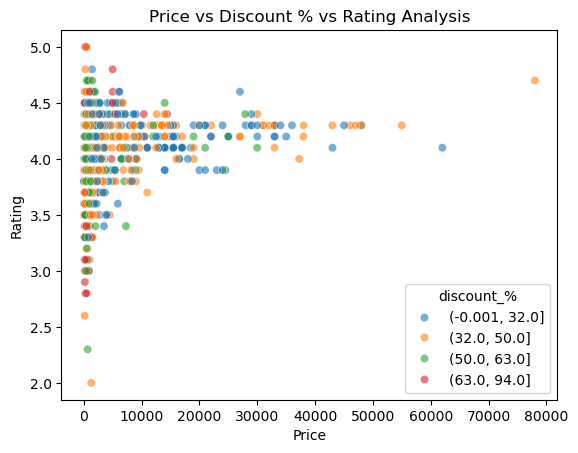

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df['discount_%'] = pd.qcut(df['discount_percentage'], 4)

sns.scatterplot(
    x='discounted_price',
    y='rating',
    hue='discount_%',
    data=df,
    alpha=0.6
)
plt.title('Price vs Discount % vs Rating Analysis')
plt.xlabel('Price')
plt.ylabel('Rating')

It is evident from the graph that for Rating>4.0 the dot colors are mostly blue and orange. This implies that most good rated products had lower discount. In the other hand, worse rated products (<3.5) are mostly of green and red which refers to the higher discount on potential worse quality products.

Text(0, 0.5, 'Sales')

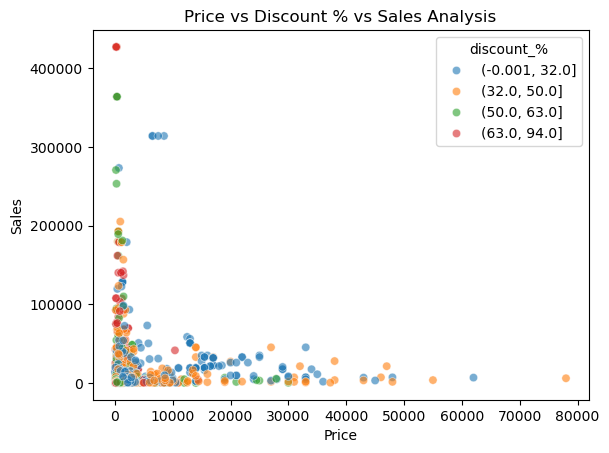

In [4]:
df['discount_%'] = pd.qcut(df['discount_percentage'], 4)

sns.scatterplot(
    x='discounted_price',
    y='rating_count',
    hue='discount_%',
    data=df,
    alpha=0.6
)
plt.title('Price vs Discount % vs Sales Analysis')
plt.xlabel('Price')
plt.ylabel('Sales')

Sales are strongly influenced by price rather than discount percentage. Lower-priced products consistently achieve higher sales volumes, while higher discounts do not necessarily translate into increased sales. This suggests that affordability plays a more critical role than discount strategies in driving product demand.

In [5]:
df['category_short'] = df['category'].str.split('|').str[0]

good_words = ['good', 'great', 'excellent', 'amazing', 'best', 'nice', 'love']
bad_words = ['bad', 'worst', 'poor', 'waste', 'terrible', 'disappointed', 'low']
def count_keywords(text, keywords):
    text = str(text).lower()
    return sum(word in text for word in keywords)

df['good_count'] = df['review_content'].apply(lambda x: count_keywords(x, good_words))
df['bad_count'] = df['review_content'].apply(lambda x: count_keywords(x, bad_words))

df['has_good'] = df['good_count'] > 0
df['has_bad'] = df['bad_count'] > 0

df.groupby('category_short')[['rating_count','has_good','has_bad']].mean()

,rating_count,has_good,has_bad
category_short,,,
Car&Motorbike,1118.000000,1.000000,0.000000
Computers&Accessories,17136.782705,0.995585,0.388521
Electronics,29997.809886,0.992395,0.593156
Health&PersonalCare,3663.000000,0.000000,1.000000
Home&Kitchen,6689.210291,0.984340,0.460850
HomeImprovement,4283.000000,1.000000,0.500000
MusicalInstruments,44441.000000,1.000000,1.000000
OfficeProducts,4828.225806,1.000000,0.354839
Toys&Games,15867.000000,1.000000,0.000000


Here, the highest selling category is Musical Instruments however all the reviews contains both bad and good words meaning they come up with diverse user satisfactory level. Cars and Motorbikes come up with 0% negative reviews. Healthcare products are almost total hassle for users as they got no good review at all. The company should focus on improving the quality of health and personal care products along with slight improvement in Electronics Products also.

In [6]:
df.groupby('category_short')[['discounted_price','rating']].mean()

,discounted_price,rating
category_short,,
Car&Motorbike,2339.000000,3.800000
Computers&Accessories,842.650375,4.154967
Electronics,5965.887833,4.081749
Health&PersonalCare,899.000000,4.000000
Home&Kitchen,2331.133803,4.040716
HomeImprovement,337.000000,4.250000
MusicalInstruments,638.000000,3.900000
OfficeProducts,301.580645,4.309677
Toys&Games,150.000000,4.300000


Car&Motorbike prodcuts come up with less price than Electronics however less rating also. This implies that price does not have any clear effect on ratings.

The ratings of musical instruments and Automibiles below 4.0 implies company should focus on their quality improvements as first priority.

<Axes: >

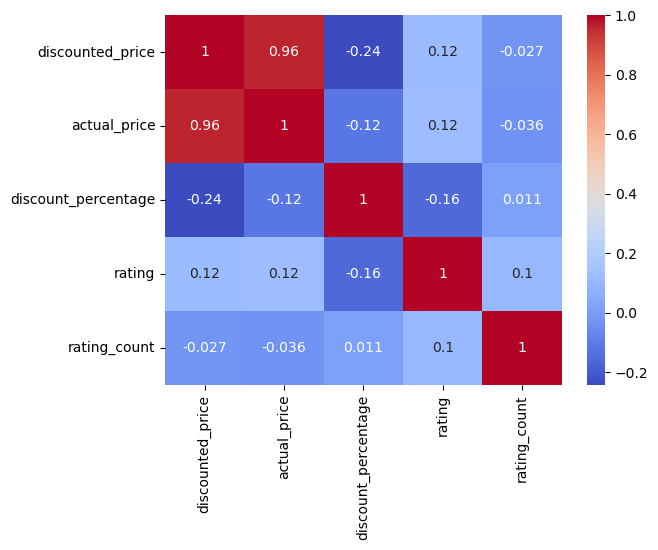

In [7]:
cols = ['discounted_price','actual_price','discount_percentage','rating','rating_count']
corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

In [8]:
corr_pairs = corr.unstack().sort_values(ascending=False)
strong = corr_pairs[(corr_pairs > 0.4) & (corr_pairs < 1)]

print(strong)

actual_price      discounted_price    0.961919
discounted_price  actual_price        0.961919
dtype: float64


Only Price and Discounted Price have strong correlations as expected price increases Discounted Price also. Other factors like Discount %, Rating, Sales don't have much strong correlation among them implying they don't affect each other that much.

In [16]:
top = df.sort_values(by='rating_count', ascending=False).head(10)
top[['product_name','rating_count','discounted_price','rating','review_title']]

,product_name,rating_count,discounted_price,rating,review_title
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0,219.0,4.4,"It's quite good and value for money,Works well..."
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0,309.0,4.4,"It's quite good and value for money,Works well..."
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0,309.0,4.4,"It's quite good and value for money,Works well..."
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0,219.0,4.4,"It's quite good and value for money,Works well..."
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,379.0,4.1,"Best value for money,HEAD PHONE POUCH NOT RECE..."
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0,349.0,4.1,"Best value for money,HEAD PHONE POUCH NOT RECE..."
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0,365.0,4.1,"Best value for money,HEAD PHONE POUCH NOT RECE..."
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0,8499.0,4.1,"Best phone for below normal use,Good mobile fo..."
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0,6499.0,4.1,"Best phone for below normal use,Good mobile fo..."
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832.0,6499.0,4.1,"Best phone for below normal use,Good mobile fo..."


Top-selling products are characterized by affordable pricing, consistently good (but not perfect) ratings, and strong ‘value for money’ perception. High review counts further reinforce trust through social proof. Additionally, these products belong to high-demand, low-involvement categories such as cables and earphones, which naturally drive frequent purchases.

In [17]:
low = df.sort_values(by='rating_count', ascending=True).head(10)
low[['product_name','rating_count','discounted_price','rating','review_title']]

,product_name,rating_count,discounted_price,rating,review_title
1458,NGI Store 2 Pieces Pet Hair Removers for Your ...,2.0,199.0,3.1,Useless
1308,Khaitan ORFin Fan heater for Home and kitchen-...,2.0,1299.0,2.0,"Bad quality,Amazing product.."
1343,"Longway Blaze 2 Rod Quartz Room Heater (White,...",4.0,929.0,3.7,"Ok product,Worth buying product,Must buyyyyy"
1070,Lifelong LLQH925 Dyno Quartz Heater 2 Power se...,4.0,1099.0,3.8,"Compact and effective,Very handy and useful pr..."
1384,VAPJA® Portable Mini Juicer Cup Blender USB Re...,4.0,649.0,3.6,"As smooth as it can and as fast as possible,Wr..."
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0,399.0,5.0,"Good,Superb quality,Good products nice one,Wo..."
1121,"C (DEVICE) Lint Remover for Woolen Clothes, El...",6.0,469.0,3.7,"Amazing results,Bestest product ever"
1222,Kitchenwell Multipurpose Portable Electronic D...,7.0,239.0,4.3,"Good quality scale but I got defective piece,N..."
299,WANBO X1 Pro (Upgraded) | Native 1080P Full HD...,7.0,13990.0,4.5,"Very nice and good product at this price,Nothi..."
1373,KNYUC MART Mini Electric Handy Room Heater Com...,8.0,778.0,3.3,"Quality Product,The Packing is very poor so th..."


Low-selling products are typically characterized by poor ratings, negative customer sentiment, and weak perceived value relative to price. Additionally, limited review counts reduce social proof, while some products belong to less frequently purchased categories, further contributing to lower sales performance.

## Summary

1. High rating products tend to have lower discount, whereas low rating products come up with higher discount.
2. Low price products sold more.
3. Discounts have limited effect in sale count.
4. Products with higher rating and rating count tend to have more sales.


Verdict: Ensuring quality and proper marketing is key to increasing sale of a product. Customers do not buy the “best” product — they buy the product that offers the best perceived value (price vs performance) with enough social proof.

BUSINESS RECOMMENDATIONS:

For Increasing Sales:
1. Optimize pricing strategy
2. Improve review quality (reduce negative feedback)
3. Boost review count (marketing / visibility)
4. Focus on high-demand categories